# Telco Churn Prediction (IBM Telco Customer Churn)
**Farouk BENKHELIFA**


**Objective:** Predict customer churn (leave service next month) using ML models, compare performance, handle class imbalance, and interpret business implications.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score
from xgboost import XGBClassifier

## 1) Load dataset
We use the IBM Telco Customer Churn dataset (Kaggle). The target is **Churn**.

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2) Quick inspection
Check types, missing values, and basic statistics.

In [ ]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## 3) Identify target, numerical features, categorical features
- Target: `Churn` (Yes/No → 1/0)
- Features: all other columns except `customerID`

In [ ]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"].map({"Yes": 1, "No": 0})

cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("X:", X.shape, "y:", y.shape)
print("\nCategorical:", list(cat_cols))
print("\nNumerical:", list(num_cols))

X: (7043, 19) y: (7043,)

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


## 4) Churn rates (TP requirement)
Compute:
- Overall churn rate
- Churn rate by one categorical variable (we choose `Contract`)

In [ ]:
overall_churn_rate = y.mean()
print(f"Overall churn rate: {overall_churn_rate:.3f} ({overall_churn_rate*100:.1f}%)")

Overall churn rate: 0.265 (26.5%)


In [ ]:
churn_by_contract = df.groupby("Contract")["Churn"].apply(lambda s: (s=="Yes").mean()).sort_values(ascending=False)
churn_by_contract

,Churn
Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


## 5) Exploratory analysis — Deliverable: **2 plots only**
We provide exactly two plots:
1) Bar plot: churn rate by contract
2) Boxplot: monthly charges by churn

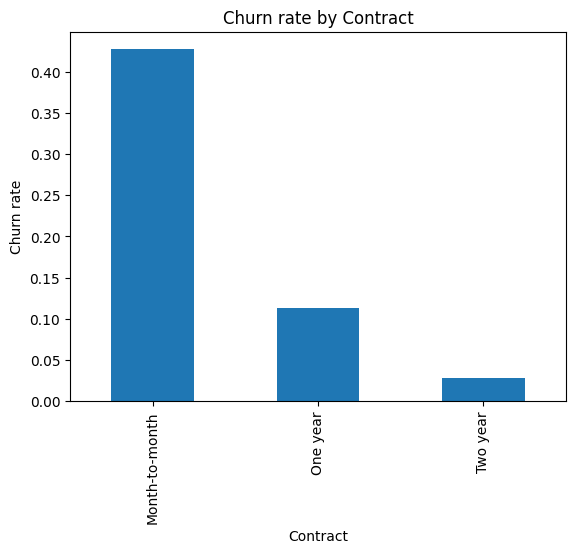

In [ ]:
plt.figure()
churn_by_contract.plot(kind="bar")
plt.ylabel("Churn rate")
plt.title("Churn rate by Contract")
plt.show()

<Figure size 640x480 with 0 Axes>

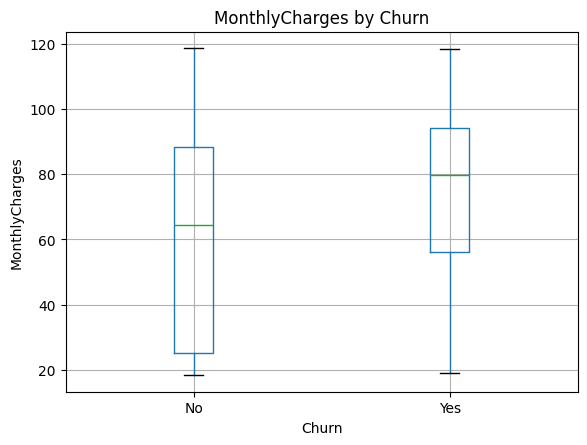

In [ ]:
plt.figure()
df.boxplot(column="MonthlyCharges", by="Churn")
plt.title("MonthlyCharges by Churn")
plt.suptitle("")  # removes automatic title
plt.ylabel("MonthlyCharges")
plt.show()

## 6) Written answer (≤150 words): Who is more likely to churn?

Customers on **month-to-month contracts** tend to churn more than those on one- or two-year contracts. Churn also appears higher among customers with **higher monthly charges**, which may indicate price sensitivity or dissatisfaction with service value. In general, churn is more frequent in segments with less commitment (shorter contracts) and potentially heavier billing pressure (higher monthly payments). These patterns suggest retention efforts should prioritize month-to-month customers, especially those with higher recurring charges, by offering contract incentives, discounts, or improved support.

## 7) Preprocessing
- Numerical: median imputation + standardization
- Categorical: most-frequent imputation + one-hot encoding (`handle_unknown="ignore"`)
We use a Pipeline/ColumnTransformer to avoid leakage inside CV.

In [ ]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

## 8) Cross-validation + metrics
We evaluate models using:
- Accuracy
- Recall for churn class (positive class = 1)
- Confusion matrix (out-of-fold)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "recall_churn": "recall"
}

## 9) Model 1 — Logistic Regression (baseline)
Baseline evaluation with cross-validation.

In [ ]:
pipe_lr = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=8000))
])

res_lr = cross_validate(pipe_lr, X, y, cv=cv, scoring=scoring)
print("LR baseline")
print("Accuracy:", res_lr["test_accuracy"].mean(), "std:", res_lr["test_accuracy"].std())
print("Recall:", res_lr["test_recall_churn"].mean(), "std:", res_lr["test_recall_churn"].std())

LR baseline
Accuracy: 0.8051929761597523 std: 0.011160167078312765
Recall: 0.5532107066565354 std: 0.031728224600458495


Confusion Matrix (LR baseline):
 [[4637  537]
 [ 835 1034]]


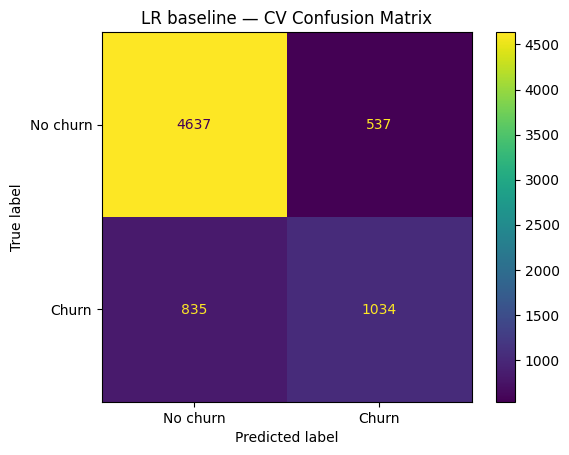

In [ ]:
y_pred_lr = cross_val_predict(pipe_lr, X, y, cv=cv)
cm_lr = confusion_matrix(y, y_pred_lr)

print("Confusion Matrix (LR baseline):\n", cm_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=["No churn", "Churn"]).plot()
plt.title("LR baseline — CV Confusion Matrix")
plt.show()

## 10) Logistic Regression — GridSearch (optimize churn recall)
We tune regularization and class weights to handle imbalance and maximize churn recall.

In [ ]:
pipe_lr = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=8000))
])

param_grid_lr = [
    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1"],
        "model__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30],
        "model__class_weight": [None, "balanced", {0:1, 1:2}, {0:1, 1:3}, {0:1, 1:4}]
    }
]

grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    cv=cv,
    scoring="recall",
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X, y)
best_lr = grid_lr.best_estimator_

print("Best LR params:", grid_lr.best_params_)
print("Best LR recall (CV):", grid_lr.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best LR params: {'model__C': 0.01, 'model__class_weight': {0: 1, 1: 4}, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best LR recall (CV): 0.8683674786024573


Confusion Matrix (LR tuned, thr=0.5):
 [[3251 1923]
 [ 246 1623]]


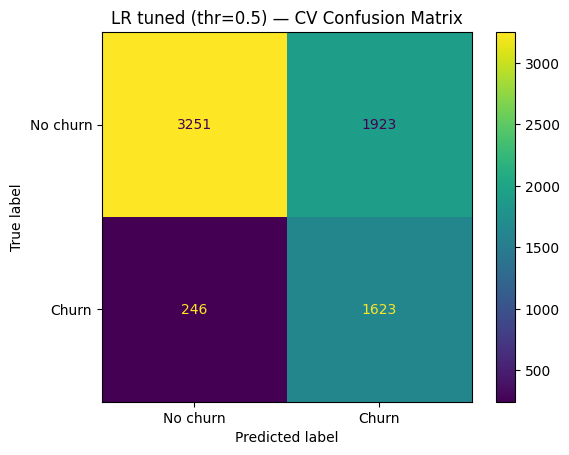

In [ ]:
y_pred_lr_tuned = cross_val_predict(best_lr, X, y, cv=cv)
cm_lr_tuned = confusion_matrix(y, y_pred_lr_tuned)

print("Confusion Matrix (LR tuned, thr=0.5):\n", cm_lr_tuned)
ConfusionMatrixDisplay(cm_lr_tuned, display_labels=["No churn", "Churn"]).plot()
plt.title("LR tuned (thr=0.5) — CV Confusion Matrix")
plt.show()

In [ ]:
# CV metrics for the tuned LR model (same CV, same scoring)
res_lr_tuned = cross_validate(best_lr, X, y, cv=cv, scoring=scoring)
print("LR tuned (best_lr) — CV metrics")
print("Accuracy:", res_lr_tuned["test_accuracy"].mean(), "std:", res_lr_tuned["test_accuracy"].std())
print("Recall:",   res_lr_tuned["test_recall_churn"].mean(), "std:", res_lr_tuned["test_recall_churn"].std())


LR tuned (best_lr) — CV metrics
Accuracy: 0.6920322480482612 std: 0.011574301755844773
Recall: 0.8683674786024573 std: 0.013486255499897768


## 11) Optional — Threshold tuning for retention strategy
Lowering the decision threshold increases recall (fewer missed churners) at the cost of more false positives (more retention offers sent).

In [ ]:
y_proba_lr = cross_val_predict(best_lr, X, y, cv=cv, method="predict_proba")[:, 1]

thresholds = np.linspace(0.1, 0.9, 17)
best_t, best_rec = None, -1

for t in thresholds:
    y_pred_t = (y_proba_lr >= t).astype(int)
    rec = recall_score(y, y_pred_t)
    prec = precision_score(y, y_pred_t, zero_division=0)
    if rec > best_rec and prec >= 0.35:
        best_rec = rec
        best_t = t

print("Chosen threshold:", best_t)
print("Recall at threshold:", best_rec)

Chosen threshold: 0.25
Recall at threshold: 0.9785981808453719


Confusion Matrix (LR tuned + threshold):
 [[1797 3377]
 [  40 1829]]


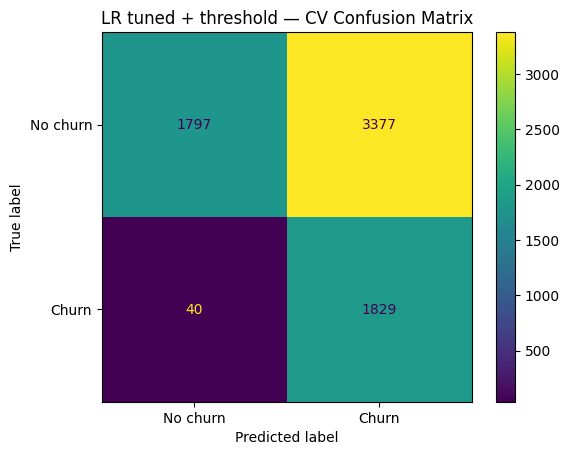

In [ ]:
y_pred_lr_thr = (y_proba_lr >= best_t).astype(int)
cm_lr_thr = confusion_matrix(y, y_pred_lr_thr)

print("Confusion Matrix (LR tuned + threshold):\n", cm_lr_thr)
ConfusionMatrixDisplay(cm_lr_thr, display_labels=["No churn", "Churn"]).plot()
plt.title("LR tuned + threshold — CV Confusion Matrix")
plt.show()

## 12) Model 2 — XGBoost
We use `scale_pos_weight` to handle class imbalance and evaluate with the same metrics.

In [ ]:
pos = (y == 1).sum()
neg = (y == 0).sum()
scale_pos_weight = neg / pos  # start with standard ratio
print("scale_pos_weight:", scale_pos_weight)

pipe_xgb = Pipeline([
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=2,
        subsample=0.85,
        colsample_bytree=0.85,
        gamma=0.1,
        reg_lambda=1.2,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    ))
])

scale_pos_weight: 2.7683253076511503


XGB baseline
Accuracy: 0.7597598030518098 std: 0.009051704514242153
Recall: 0.7132184484810253 std: 0.014429824511535651
Confusion Matrix (XGB baseline):
 [[4018 1156]
 [ 536 1333]]


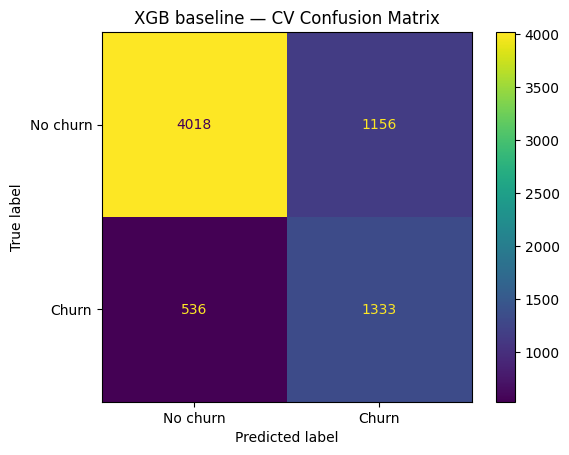

In [ ]:
res_xgb = cross_validate(pipe_xgb, X, y, cv=cv, scoring=scoring)
print("XGB baseline")
print("Accuracy:", res_xgb["test_accuracy"].mean(), "std:", res_xgb["test_accuracy"].std())
print("Recall:", res_xgb["test_recall_churn"].mean(), "std:", res_xgb["test_recall_churn"].std())

y_pred_xgb = cross_val_predict(pipe_xgb, X, y, cv=cv)
cm_xgb = confusion_matrix(y, y_pred_xgb)
print("Confusion Matrix (XGB baseline):\n", cm_xgb)
ConfusionMatrixDisplay(cm_xgb, display_labels=["No churn", "Churn"]).plot()
plt.title("XGB baseline — CV Confusion Matrix")
plt.show()

## 13) XGBoost — GridSearch (optimize churn recall)
We tune key parameters with recall as the optimization objective.

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best XGB params: {'model__learning_rate': 0.02, 'model__max_depth': 3, 'model__n_estimators': 400, 'model__subsample': 0.9}
Best XGB recall (CV): 0.803102464480796
Confusion Matrix (XGB tuned):
 [[3804 1370]
 [ 368 1501]]


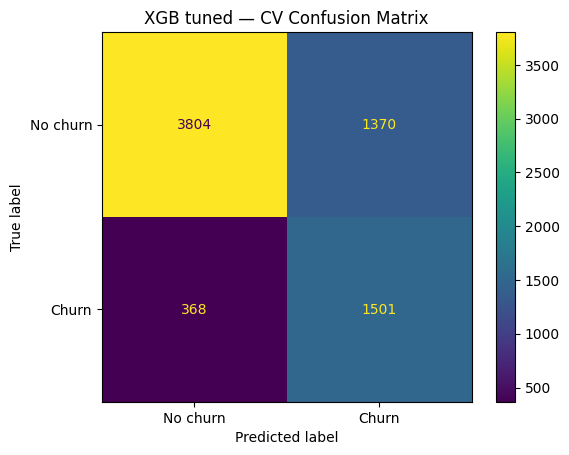

In [ ]:
param_grid_xgb = {
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.02, 0.03, 0.05],
    "model__n_estimators": [400, 600, 800],
    "model__subsample": [0.8, 0.9],
}

grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring="recall",
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X, y)
best_xgb = grid_xgb.best_estimator_

print("Best XGB params:", grid_xgb.best_params_)
print("Best XGB recall (CV):", grid_xgb.best_score_)

y_pred_xgb_tuned = cross_val_predict(best_xgb, X, y, cv=cv)
cm_xgb_tuned = confusion_matrix(y, y_pred_xgb_tuned)

print("Confusion Matrix (XGB tuned):\n", cm_xgb_tuned)
ConfusionMatrixDisplay(cm_xgb_tuned, display_labels=["No churn", "Churn"]).plot()
plt.title("XGB tuned — CV Confusion Matrix")
plt.show()

In [ ]:
# CV metrics for the tuned XGB model (same CV, same scoring)
res_xgb_tuned = cross_validate(best_xgb, X, y, cv=cv, scoring=scoring)
print("XGB tuned (best_xgb) — CV metrics")
print("Accuracy:", res_xgb_tuned["test_accuracy"].mean(), "std:", res_xgb_tuned["test_accuracy"].std())
print("Recall:",   res_xgb_tuned["test_recall_churn"].mean(), "std:", res_xgb_tuned["test_recall_churn"].std())


XGB tuned (best_xgb) — CV metrics
Accuracy: 0.7532288373443448 std: 0.011075831410824981
Recall: 0.803102464480796 std: 0.01091945353355549


## 14) Model comparison (churn detection)
We compare the two tuned models (best_lr vs best_xgb) using the same CV protocol and the default threshold 0.5:
- Accuracy
- Recall (churn class = 1)
- Confusion matrix (out-of-fold predictions)

The better model for churn detection is the one with higher recall and lower FN, because missed churners are costly.

In [ ]:
def summarize_cm(cm):
    tn, fp, fn, tp = cm.ravel()
    return {"TN": tn, "FP": fp, "FN": fn, "TP": tp}

print("LR tuned (thr=0.5):", summarize_cm(cm_lr_tuned))
print("LR tuned + threshold:", summarize_cm(cm_lr_thr))
print("XGB tuned:", summarize_cm(cm_xgb_tuned))

LR tuned (thr=0.5): {'TN': np.int64(3251), 'FP': np.int64(1923), 'FN': np.int64(246), 'TP': np.int64(1623)}
LR tuned + threshold: {'TN': np.int64(1797), 'FP': np.int64(3377), 'FN': np.int64(40), 'TP': np.int64(1829)}
XGB tuned: {'TN': np.int64(3804), 'FP': np.int64(1370), 'FN': np.int64(368), 'TP': np.int64(1501)}


In [ ]:
# Final decision under a single consistent policy:
# - tuned LR at default threshold (0.5)
# - tuned XGB at default threshold (0.5)
# - both evaluated with out-of-fold predictions

y_pred_lr_final  = cross_val_predict(best_lr,  X, y, cv=cv)
y_pred_xgb_final = cross_val_predict(best_xgb, X, y, cv=cv)

cm_lr_final  = confusion_matrix(y, y_pred_lr_final)
cm_xgb_final = confusion_matrix(y, y_pred_xgb_final)

def acc_recall_from_cm(cm):
    tn, fp, fn, tp = cm.ravel()
    acc = (tn + tp) / cm.sum()
    rec = tp / (tp + fn)
    return acc, rec, fn, fp

acc_lr, rec_lr, fn_lr, fp_lr = acc_recall_from_cm(cm_lr_final)
acc_xg, rec_xg, fn_xg, fp_xg = acc_recall_from_cm(cm_xgb_final)

print("FINAL (OOF) — LR tuned @0.5:",  {"acc": acc_lr, "recall": rec_lr, "FN": fn_lr, "FP": fp_lr})
print("FINAL (OOF) — XGB tuned @0.5:", {"acc": acc_xg, "recall": rec_xg, "FN": fn_xg, "FP": fp_xg})

winner = "LR tuned" if rec_lr > rec_xg else "XGB tuned"
print("Winner for churn detection (by recall @0.5):", winner)


FINAL (OOF) — LR tuned @0.5: {'acc': np.float64(0.6921766292772966), 'recall': np.float64(0.8683788121990369), 'FN': np.int64(246), 'FP': np.int64(1922)}
FINAL (OOF) — XGB tuned @0.5: {'acc': np.float64(0.753230157603294), 'recall': np.float64(0.803103263777421), 'FN': np.int64(368), 'FP': np.int64(1370)}
Winner for churn detection (by recall @0.5): LR tuned


## 15) Commercial implications
- **False Negatives (FN):** churners we failed to detect → lost customers (high cost).
- **False Positives (FP):** loyal customers flagged as churn → extra retention offers (marketing cost).
If the company prioritizes minimizing churn loss, we prefer a model/threshold with low FN even if FP increases.